In [1]:
import numpy as np

results = np.load("data_Gauss/results.npy", allow_pickle=True).item()

vec_U = results['vec_U']
vec_ns = results['vec_ns']
vec_n_out = results['vec_target_n_out']
gammas = results['gammas']

print(f"U: {vec_U}")
print(f"ns: {vec_ns}")
print(f"n_out contstraint: {vec_n_out}")
print(f"gammas: {gammas}")

U: [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
ns: [  0.1          0.11513954   0.13257114   0.1526418    0.17575106
   0.20235896   0.23299518   0.26826958   0.30888436   0.35564803
   0.40949151   0.47148664   0.54286754   0.62505519   0.71968567
   0.82864277   0.95409548   1.09854114   1.26485522   1.45634848
   1.67683294   1.93069773   2.22299648   2.55954792   2.9470517
   3.39322177   3.90693994   4.49843267   5.17947468   5.96362332
   6.86648845   7.90604321   9.10298178  10.48113134  12.06792641
  13.89495494  15.9985872   18.42069969  21.20950888  24.42053095
  28.11768698  32.37457543  37.2759372   42.9193426   49.41713361
  56.89866029  65.51285569  75.43120063  86.85113738 100.        ]
n_out contstraint: [None, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.5, 1.0]
gammas: [0.0, 0.1, 1.0]


In [2]:
np.abs(results[(vec_U[0], vec_ns[-1], vec_n_out[0], gammas[0])]['alpha']) ** 2

np.float64(0.03314160370500489)

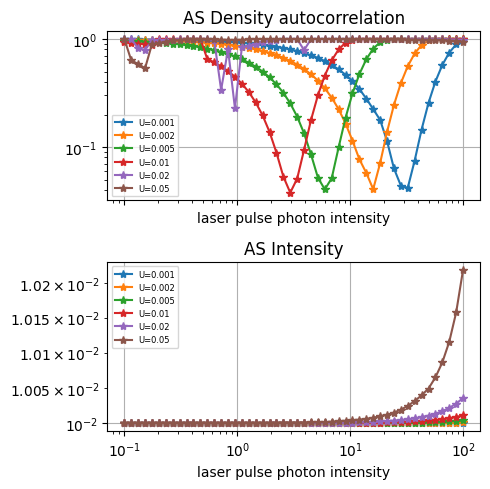

<Figure size 500x200 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt

n_out_tar = 0.01
gamma = 0.

fig, ax = plt.subplots(2,1, figsize=(5,5), sharex=True)
for U in vec_U[:-1]:
    dat_g2 = []
    for ns in vec_ns:
        dat_g2.append(results[(U, ns, n_out_tar, gamma)]['g2'])

    ax[0].loglog(vec_ns, dat_g2, "*-", label=f"U={U}")

#plt.ylim(0,0.3)
ax[0].grid(True)
ax[0].legend(fontsize=6)
ax[0].set_title("AS Density autocorrelation")
ax[0].set_xlabel(r"laser pulse photon intensity")

plt.figure(figsize=(5,2))
for U in vec_U[:-1]:
    dat_n_out = []
    for ns in vec_ns:
        n_out = np.abs(results[(U, ns, n_out_tar, gamma)]['alpha']) ** 2 \
            + np.abs(results[(U, ns, n_out_tar, gamma)]['N'])
        dat_n_out.append(n_out)

    ax[1].loglog(vec_ns, dat_n_out, "*-", label=f"U={U}")

ax[1].grid(True)
ax[1].legend(fontsize=6)
ax[1].set_xlabel(r"laser pulse photon intensity")
ax[1].set_title("AS Intensity")

fig.tight_layout()

In [42]:
results[(vec_U[0],vec_ns[0])]['g2']

np.complex128(0.19651278031228242+0j)